# Deepfake Image Detection — Real vs Fake Faces

Binary classifier over the CIPLAB `real-and-fake-face-detection` dataset, built on
**MobileNetV2 transfer learning**.

**This notebook is self-contained.** Every function it uses is defined in it. It
imports nothing from `src/`, needs no `PYTHONPATH`, and no command line. Open it,
`Cell → Run All`, and it runs start to finish: data, EDA, split, pipeline, model,
training, fine-tuning, evaluation, Grad-CAM, inference, save.

Run order is source order. There is no cell that has to be run twice, and nothing
later in the notebook is needed by anything earlier.

### Method highlights

Six decisions carry the correctness of this notebook, each explained where it
appears:

| Concern | Approach |
|---|---|
| Metrics | Brier score, log loss and calibration; every headline number reported with its baseline and a bootstrap confidence interval |
| Checkpoint callback | `mode='max'` stated explicitly, never left to Keras' `'auto'` inference |
| Input scaling | `Rescaling(1/127.5, offset=-1)` → `[-1, 1]`, inside the model |
| Augmentation | a model layer: re-randomised every epoch, off at inference |
| Labels | the class name is always derived from the index, never a literal |
| Test set | sealed three-way split; validation drives every decision |

## 1. Setup

Imports, versions, hardware, and the random seeds that make the split reproducible.

In [1]:
import json, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (average_precision_score, brier_score_loss,
                             classification_report, confusion_matrix, log_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

SEED = 1337
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
# In TF 2.15 the bundled keras shim has no __version__ attribute, so fall back.
print("Keras      :", getattr(keras, "__version__", tf.__version__))
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Hardware   :", len(gpus), "GPU(s)")
else:
    print("Hardware   : CPU only (training takes a few minutes)")

TensorFlow : 2.20.0
Keras      : 3.12.0
Hardware   : CPU only (training takes a few minutes)


## 2. Configuration

Every knob for the whole notebook, in one place. Change something here and re-run
from this cell down; nothing below hardcodes a value.

In [2]:
CONFIG = {
    # where the images are; must contain the two class folders below
    "data_root":      Path("data/real_and_fake_face"),
    "fake_dir":       "training_fake",     # label 0
    "real_dir":       "training_real",     # label 1

    "image_size":     (224, 224),          # MobileNetV2's native size
    "batch_size":     32,

    # three-way split; the test part is not touched until section 9
    "split":          {"train": 0.70, "val": 0.15, "test": 0.15},

    # stage 1: frozen backbone, head only.  stage 2: fine-tune the top layers
    "stage1_epochs":  20,
    "stage1_lr":      1e-4,
    "stage2_epochs":  15,
    "stage2_lr":      1e-5,
    "unfreeze_last":  40,                  # of MobileNetV2's 154 layers
    "dropout":        0.2,

    "es_patience":    6,                   # early stopping
    "abstain_margin": 0.10,                # uncertainty band around the threshold
    "bootstrap":      2000,                # resamples for confidence intervals

    "out_dir":        Path("artifacts/notebook"),
}
CONFIG["out_dir"].mkdir(parents=True, exist_ok=True)

# fake = 0, real = 1. The model's sigmoid output is therefore P(real), NEVER
# P(fake). It is written down once here and never re-typed as a literal, so the
# polarity cannot silently disagree anywhere downstream.
CLASS_NAMES = ["fake", "real"]

for key, value in CONFIG.items():
    print(f"{key:15s} {value}")
print(f"{'CLASS_NAMES':15s} {CLASS_NAMES}   (index = label: fake=0, real=1)")

data_root       data\real_and_fake_face
fake_dir        training_fake
real_dir        training_real
image_size      (224, 224)
batch_size      32
split           {'train': 0.7, 'val': 0.15, 'test': 0.15}
stage1_epochs   20
stage1_lr       0.0001
stage2_epochs   15
stage2_lr       1e-05
unfreeze_last   40
dropout         0.2
es_patience     6
abstain_margin  0.1
bootstrap       2000
out_dir         artifacts\notebook
CLASS_NAMES     ['fake', 'real']   (index = label: fake=0, real=1)


## 3. Find the dataset

Expected layout:

```
data/real_and_fake_face/
    training_real/   real_00001.jpg ...
    training_fake/   easy_100_1111.jpg ...
```

If it is missing, download it from
<https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection> and extract
it there, or point `CONFIG["data_root"]` somewhere else.

The fake filenames carry metadata that is worth keeping: `easy_100_1111.jpg` means
difficulty `easy`, and the 4-bit mask `1111` says which regions were manipulated
(left eye, right eye, nose, mouth).

In [3]:
def difficulty_of(name):
    head = name.split("_", 1)[0].lower()
    return head if head in {"easy", "mid", "hard"} else "none"

def region_mask_of(name):
    tail = Path(name).stem.rsplit("_", 1)[-1]
    return tail if len(tail) == 4 and set(tail) <= {"0", "1"} else ""

def discover(config):
    rows = []
    for label, class_name in enumerate(CLASS_NAMES):          # fake=0, real=1
        folder = config["data_root"] / config[f"{class_name}_dir"]
        if not folder.is_dir():
            raise FileNotFoundError(
                f"missing folder: {folder.resolve()}\n"
                f"Fix CONFIG['data_root'] / CONFIG['{class_name}_dir'] and re-run this cell."
            )
        files = sorted(p for p in folder.iterdir()
                       if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
        if not files:
            raise FileNotFoundError(f"no images in {folder.resolve()}")
        for path in files:
            rows.append({"path": str(path), "filename": path.name,
                         "class_name": class_name, "label": label,
                         "difficulty": difficulty_of(path.name),
                         "region_mask": region_mask_of(path.name)})
    return pd.DataFrame(rows)

files = discover(CONFIG)

print(f"found {len(files)} images")
print(files["class_name"].value_counts().to_string())
files.head()

found 2041 images
class_name
real    1081
fake     960


,path,filename,class_name,label,difficulty,region_mask
0,data\real_and_fake_face\training_fake\easy_100...,easy_100_1111.jpg,fake,0,easy,1111
1,data\real_and_fake_face\training_fake\easy_101...,easy_101_0010.jpg,fake,0,easy,0010
2,data\real_and_fake_face\training_fake\easy_102...,easy_102_0101.jpg,fake,0,easy,0101
3,data\real_and_fake_face\training_fake\easy_103...,easy_103_1111.jpg,fake,0,easy,1111
4,data\real_and_fake_face\training_fake\easy_104...,easy_104_1000.jpg,fake,0,easy,1000


## 4. Exploratory look at the data

real       1081  (53.0%)
fake        960  (47.0%)
total      2041
imbalance 1.13x   -> class weights not needed

MAJORITY-CLASS BASELINE = 0.5296
Every accuracy below has to be read against that number. Predicting
'real' for everything already scores it, and learns nothing.


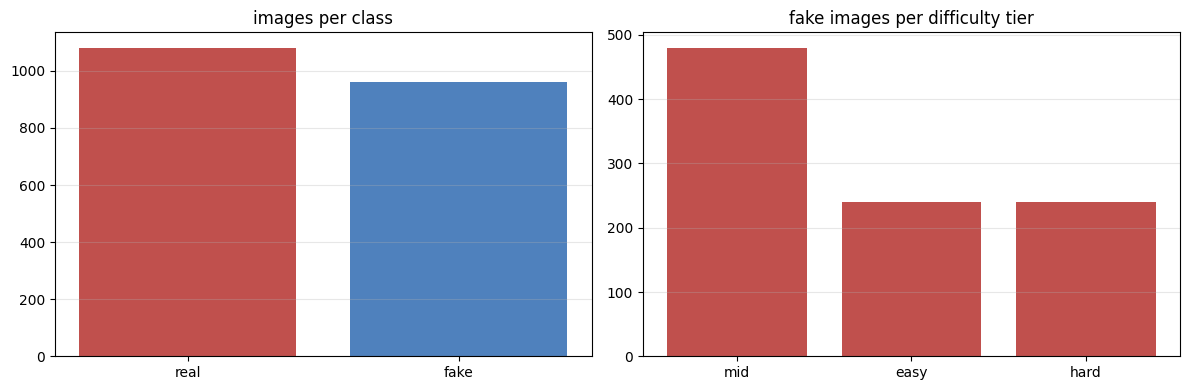

In [4]:
counts = files["class_name"].value_counts()
total = int(counts.sum())
imbalance = counts.max() / counts.min()
majority = counts.max() / total

print(f"real      {counts['real']:5d}  ({100*counts['real']/total:.1f}%)")
print(f"fake      {counts['fake']:5d}  ({100*counts['fake']/total:.1f}%)")
print(f"total     {total:5d}")
print(f"imbalance {imbalance:.2f}x   -> class weights {'needed' if imbalance > 1.5 else 'not needed'}")
print()
print(f"MAJORITY-CLASS BASELINE = {majority:.4f}")
print("Every accuracy below has to be read against that number. Predicting")
print("'real' for everything already scores it, and learns nothing.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.index, counts.values, color=["#c0504d", "#4f81bd"])
axes[0].set_title("images per class"); axes[0].grid(alpha=0.3, axis="y")

tiers = files[files.class_name == "fake"]["difficulty"].value_counts()
axes[1].bar(tiers.index, tiers.values, color="#c0504d")
axes[1].set_title("fake images per difficulty tier"); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

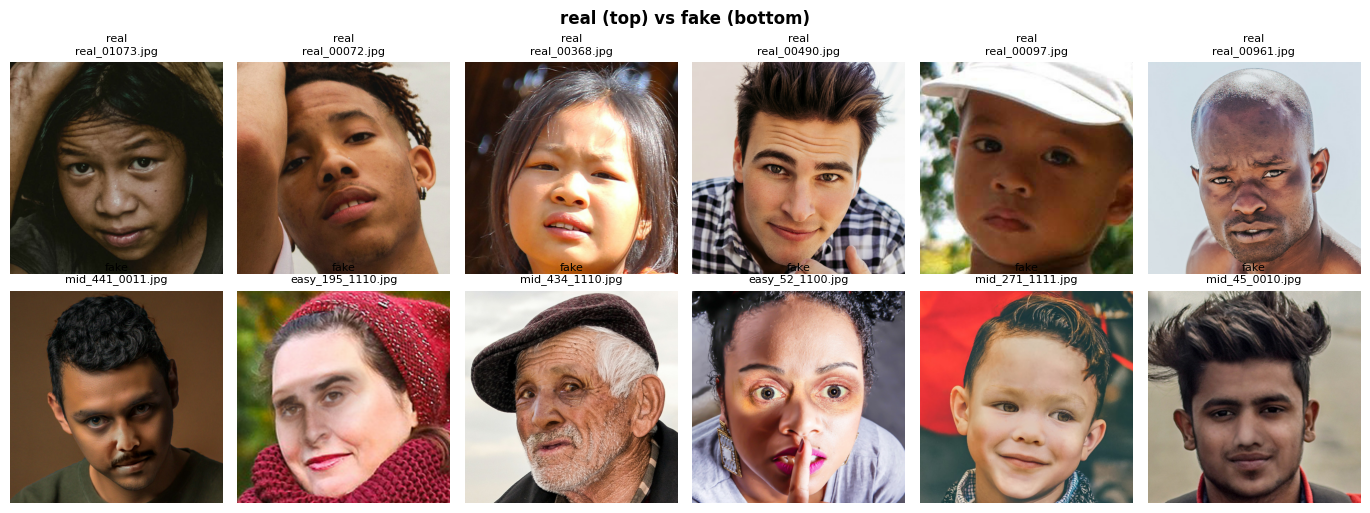

In [5]:
# A look at the actual images, six per class.
def show_samples(frame, n=6):
    fig, axes = plt.subplots(2, n, figsize=(2.3 * n, 5.2))
    for row, class_name in enumerate(CLASS_NAMES[::-1]):          # real on top
        picks = frame[frame.class_name == class_name].sample(n, random_state=SEED)
        for col, (_, record) in enumerate(picks.iterrows()):
            image = tf.io.decode_image(tf.io.read_file(record["path"]), channels=3)
            axes[row, col].imshow(image.numpy()); axes[row, col].axis("off")
            axes[row, col].set_title(f"{class_name}\n{record['filename'][:18]}", fontsize=8)
    plt.suptitle("real (top) vs fake (bottom)", fontweight="bold")
    plt.tight_layout(); plt.show()

show_samples(files)

median native size : 600 x 600
training size      : 224 x 224

That downsampling is the single biggest limitation of this approach:
forgery traces (blending seams, noise inconsistency, compression history)
are high-frequency, and resizing is a low-pass filter. See section 12.


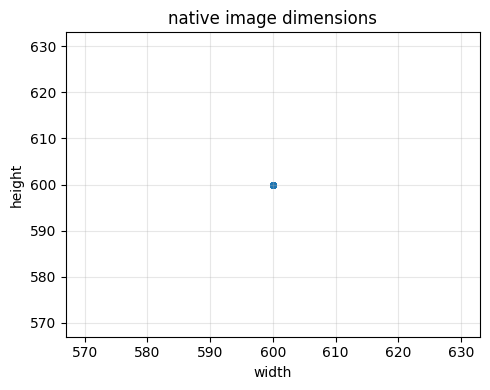

In [6]:
# Native resolution, sampled, so we know what resizing to 224 costs us.
sample = files.sample(min(150, len(files)), random_state=SEED)
shapes = np.array([tf.io.decode_image(tf.io.read_file(p), channels=3).shape[:2]
                   for p in sample["path"]])

print(f"median native size : {int(np.median(shapes[:,1]))} x {int(np.median(shapes[:,0]))}")
print(f"training size      : {CONFIG['image_size'][1]} x {CONFIG['image_size'][0]}")
print()
print("That downsampling is the single biggest limitation of this approach:")
print("forgery traces (blending seams, noise inconsistency, compression history)")
print("are high-frequency, and resizing is a low-pass filter. See section 12.")

plt.figure(figsize=(5, 4))
plt.scatter(shapes[:, 1], shapes[:, 0], alpha=0.4, s=12)
plt.xlabel("width"); plt.ylabel("height"); plt.title("native image dimensions")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Split the data — train / validation / **sealed test**

A two-way split that reuses one validation set for early stopping, for checkpoint
selection *and* for the headline number makes the reported figure optimistic by
construction.

Here there are three parts. Validation drives every decision; the test part is not
looked at until section 9, once nothing can be changed in response to it.

The split is stratified per class (so the class ratio survives) and seeded (so it
is the same every run), and it is written to disk so a later session sees exactly
the same images.

In [7]:
def make_split(frame, fractions, seed):
    rng = np.random.default_rng(seed)
    assignment = np.empty(len(frame), dtype=object)
    for label in sorted(frame["label"].unique()):               # stratified
        idx = frame.index[frame["label"] == label].to_numpy()
        rng.shuffle(idx)
        n_train = int(round(len(idx) * fractions["train"]))
        n_val = int(round(len(idx) * fractions["val"]))
        assignment[idx[:n_train]] = "train"
        assignment[idx[n_train:n_train + n_val]] = "val"
        assignment[idx[n_train + n_val:]] = "test"
    out = frame.copy()
    out["split"] = assignment
    return out

data = make_split(files, CONFIG["split"], SEED)

# An image may appear in exactly one split. Cheap to check, fatal if wrong.
assert data.groupby("path")["split"].nunique().max() == 1, "a file leaked across splits"
assert not data["split"].isna().any(), "some file was never assigned"
for part in ("train", "val", "test"):
    assert set(data[data.split == part]["label"]) == {0, 1}, f"{part} lost a class"

data.to_csv(CONFIG["out_dir"] / "split_manifest.csv", index=False)

table = data.groupby(["split", "class_name"]).size().unstack(fill_value=0)
table = table.reindex(["train", "val", "test"])
table["total"] = table.sum(axis=1)
table["majority_baseline"] = (table[CLASS_NAMES].max(axis=1) / table["total"]).round(4)
print(table.to_string())
print("\nsaved:", CONFIG["out_dir"] / "split_manifest.csv")

class_name  fake  real  total  majority_baseline
split                                           
train        672   757   1429             0.5297
val          144   162    306             0.5294
test         144   162    306             0.5294

saved: artifacts\notebook\split_manifest.csv


## 6. Input pipeline

Operation order is the whole point here. In a pipeline shaped like
`map(preprocess) → map(augment) → cache() → shuffle()`, the `cache()` after the
augment step **stores the first epoch's random transforms and replays them
forever**, so augmentation adds one fixed extra view instead of a new one each
epoch.

Here the pipeline only decodes and resizes:

```
slices → map(decode+resize) → cache → [shuffle, train only] → batch → prefetch
```

It emits **raw pixels in [0, 255]** and does no normalisation and no augmentation.
Both of those are layers inside the model (section 7), which also means the saved
model carries its own preprocessing and inference can never disagree with training.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

def decode(path, label, size):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image = tf.image.resize(image, size, method="bilinear")
    image = tf.cast(image, tf.float32)
    image.set_shape([size[0], size[1], 3])
    return image, tf.cast(label, tf.float32)

def make_dataset(frame, config, shuffle):
    size = config["image_size"]
    ds = tf.data.Dataset.from_tensor_slices(
        (frame["path"].to_numpy(), frame["label"].to_numpy().astype("float32")))
    ds = ds.map(lambda p, y: decode(p, y, size), num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                                   # decode once, not every epoch
    if shuffle:                                       # validation/test keep file order
        ds = ds.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(config["batch_size"]).prefetch(AUTOTUNE)

train_df = data[data.split == "train"].reset_index(drop=True)
val_df   = data[data.split == "val"].reset_index(drop=True)
test_df  = data[data.split == "test"].reset_index(drop=True)

train_ds = make_dataset(train_df, CONFIG, shuffle=True)
val_ds   = make_dataset(val_df,   CONFIG, shuffle=False)
test_ds  = make_dataset(test_df,  CONFIG, shuffle=False)

images, labels = next(iter(train_ds))
print("batch          :", tuple(images.shape), images.dtype.name)
print("pixel range    :", float(images.numpy().min()), "to", float(images.numpy().max()),
      " <- raw, on purpose: the model normalises")
print("labels in batch:", {CLASS_NAMES[int(v)]: int((labels.numpy() == v).sum())
                           for v in np.unique(labels.numpy())})
print("batches        : train", len(train_ds), "| val", len(val_ds), "| test", len(test_ds))

batch          : (32, 224, 224, 3) float32
pixel range    : 0.0 to 255.0  <- raw, on purpose: the model normalises
labels in batch: {'fake': 22, 'real': 10}
batches        : train 45 | val 10 | test 10


In [9]:
# Class weights, but only if the imbalance is big enough to matter (it is not here).
counts = train_df["label"].value_counts().to_dict()
ratio = max(counts.values()) / min(counts.values())
if ratio > 1.5:
    n = sum(counts.values())
    class_weight = {int(k): n / (2 * v) for k, v in counts.items()}
    print(f"imbalance {ratio:.2f}x -> class weights {class_weight}")
else:
    class_weight = None
    print(f"imbalance {ratio:.2f}x -> no class weights needed")

imbalance 1.13x -> no class weights needed


## 7. The model

```
input (224, 224, 3), raw pixels 0-255
  → augmentation      flip / small rotate / zoom / shift / contrast   (training only)
  → preprocess        Rescaling(1/127.5, offset=-1)  →  [-1, 1]
  → MobileNetV2       ImageNet weights, no top, BatchNorm in inference mode
  → GlobalAveragePooling2D
  → Dropout
  → Dense(1, linear)  ← a LOGIT, not a probability
```

Three load-bearing decisions live in this cell:

1. **Preprocessing is a layer.** MobileNetV2's ImageNet weights were trained on
   `[-1, 1]`; feeding `[0, 1]` would put every activation off-distribution. Putting
   it in the model also means `predict` cannot use different arithmetic.
2. **Augmentation is a layer**, so it re-randomises every epoch and switches itself
   off at inference. It is also deliberately mild: no vertical flips (faces are
   never upside down) and little photometric jitter, because that jitter erases the
   very high-frequency evidence this task depends on.
3. **The output is linear.** Training uses `from_logits=True`, which is numerically
   stable, and Grad-CAM (section 10) can differentiate the logit instead of a
   saturated sigmoid whose gradients vanish. `sigmoid(logit) = P(real)`.

In [10]:
def build_model(config):
    backbone = keras.applications.MobileNetV2(
        include_top=False, weights="imagenet",
        input_shape=(*config["image_size"], 3))
    backbone.trainable = False                      # stage 1: frozen

    augmentation = keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.05, seed=SEED),
        layers.RandomTranslation(0.05, 0.05, seed=SEED),
        layers.RandomContrast(0.05, seed=SEED),
    ], name="augmentation")

    inputs = keras.Input(shape=(*config["image_size"], 3), name="image")
    x = augmentation(inputs)
    x = layers.Rescaling(1 / 127.5, offset=-1.0, name="preprocess")(x)   # [-1, 1]
    x = backbone(x, training=False)     # keeps BatchNorm on ImageNet statistics
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(config["dropout"], name="dropout")(x)
    outputs = layers.Dense(1, activation=None, name="logit")(x)          # LOGIT
    return keras.Model(inputs, outputs, name="deepfake_classifier"), backbone

def compile_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.0),
                 keras.metrics.AUC(name="auc_roc", from_logits=True),
                 keras.metrics.AUC(name="auc_pr", curve="PR", from_logits=True)])
    return model

model, backbone = build_model(CONFIG)
compile_model(model, CONFIG["stage1_lr"])
model.summary()

Model: "deepfake_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess (Rescaling)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logit (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Proof that the preprocessing layer does what the backbone expects.
preprocess = model.get_layer("preprocess")
print("pixel   0 ->", float(preprocess(tf.zeros((1, 8, 8, 3)))[0, 0, 0, 0]))
print("pixel 255 ->", float(preprocess(tf.fill((1, 8, 8, 3), 255.0))[0, 0, 0, 0]))
print("MobileNetV2 expects exactly this [-1, 1] range.")

trainable = int(sum(np.prod(w.shape) for w in model.trainable_weights))
frozen = int(sum(np.prod(w.shape) for w in model.non_trainable_weights))
print(f"\ntrainable parameters : {trainable:,}   (this is a linear probe on frozen features)")
print(f"frozen parameters    : {frozen:,}")

pixel   0 -> -1.0
pixel 255 -> 1.0
MobileNetV2 expects exactly this [-1, 1] range.

trainable parameters : 1,281   (this is a linear probe on frozen features)
frozen parameters    : 2,257,984


## 8. Training

### Stage 1 — frozen backbone, train the head

One detail here is critical. Keras callbacks default to `mode='auto'` and infer
the direction from the metric *name*: names containing `acc` are maximised,
everything else is **minimised**. `val_auc` contains `auc`, not `acc`, so a run
left on the default would spend its whole time minimising AUC, checkpointing the
worst epoch, and `restore_best_weights` would then load that epoch back.

Below, `mode="max"` is written out. Watch the checkpoint lines: the numbers must go **up**.

In [12]:
def callbacks_for(tag, config):
    path = config["out_dir"] / f"model_{tag}.keras"
    return path, [
        keras.callbacks.EarlyStopping(
            monitor="val_auc_roc", mode="max",          # explicit, never 'auto'
            patience=config["es_patience"], restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(
            filepath=str(path), monitor="val_auc_roc", mode="max",   # explicit
            save_best_only=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(               # the ONLY lr controller;
            monitor="val_loss", mode="min",              # two at once would fight
            factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]

stage1_path, stage1_callbacks = callbacks_for("stage1", CONFIG)

print("STAGE 1 — head only, backbone frozen")
history1 = model.fit(train_ds, validation_data=val_ds,
                     epochs=CONFIG["stage1_epochs"],
                     callbacks=stage1_callbacks,
                     class_weight=class_weight, verbose=2)
best1 = max(history1.history["val_auc_roc"])
print(f"\nstage 1 best validation AUC: {best1:.4f}")

STAGE 1 — head only, backbone frozen
Epoch 1/20

Epoch 1: val_auc_roc improved from None to 0.58160, saving model to artifacts\notebook\model_stage1.keras
45/45 - 29s - 643ms/step - accuracy: 0.5073 - auc_pr: 0.5456 - auc_roc: 0.5111 - loss: 0.7503 - val_accuracy: 0.5458 - val_auc_pr: 0.5668 - val_auc_roc: 0.5816 - val_loss: 0.6944 - learning_rate: 1.0000e-04
Epoch 2/20

Epoch 2: val_auc_roc improved from 0.58160 to 0.58858, saving model to artifacts\notebook\model_stage1.keras
45/45 - 18s - 407ms/step - accuracy: 0.5199 - auc_pr: 0.5527 - auc_roc: 0.5283 - loss: 0.7421 - val_accuracy: 0.5588 - val_auc_pr: 0.5724 - val_auc_roc: 0.5886 - val_loss: 0.6902 - learning_rate: 1.0000e-04
Epoch 3/20

Epoch 3: val_auc_roc improved from 0.58858 to 0.59686, saving model to artifacts\notebook\model_stage1.keras
45/45 - 20s - 436ms/step - accuracy: 0.5325 - auc_pr: 0.5754 - auc_roc: 0.5432 - loss: 0.7284 - val_accuracy: 0.5621 - val_auc_pr: 0.5798 - val_auc_roc: 0.5969 - val_loss: 0.6861 - learning

### Stage 2 — fine-tune the top of the backbone

Unfreeze the last 40 layers at a 10x lower learning rate, so the pre-trained
features get nudged rather than overwritten.

Every `BatchNormalization` layer stays frozen: unfreezing them would let a
1,400-image dataset overwrite moving statistics that were estimated over a
million ImageNet images.

Recompiling is not optional: a change to `trainable` only takes effect when the
training function is rebuilt.

In [13]:
backbone.trainable = True
cut = len(backbone.layers) - CONFIG["unfreeze_last"]
unfrozen = frozen_bn = 0
for i, layer in enumerate(backbone.layers):
    if i < cut:
        layer.trainable = False
    elif isinstance(layer, layers.BatchNormalization):
        layer.trainable = False                     # never fine-tune BN here
        frozen_bn += 1
    else:
        layer.trainable = True
        unfrozen += 1

compile_model(model, CONFIG["stage2_lr"])           # mandatory after the change
print(f"backbone layers {len(backbone.layers)} | unfrozen {unfrozen} | "
      f"BatchNorm kept frozen {frozen_bn} | frozen {cut}")
print(f"learning rate {CONFIG['stage1_lr']} -> {CONFIG['stage2_lr']}")

stage2_path, stage2_callbacks = callbacks_for("stage2", CONFIG)
done = len(history1.history["loss"])

print("\nSTAGE 2 — fine-tuning")
history2 = model.fit(train_ds, validation_data=val_ds,
                     epochs=done + CONFIG["stage2_epochs"],
                     initial_epoch=done,             # keeps the epoch axis continuous
                     callbacks=stage2_callbacks,
                     class_weight=class_weight, verbose=2)
best2 = max(history2.history["val_auc_roc"])
print(f"\nstage 2 best validation AUC: {best2:.4f}  (stage 1 was {best1:.4f})")

backbone layers 154 | unfrozen 26 | BatchNorm kept frozen 14 | frozen 114
learning rate 0.0001 -> 1e-05

STAGE 2 — fine-tuning
Epoch 21/35

Epoch 21: val_auc_roc improved from None to 0.68964, saving model to artifacts\notebook\model_stage2.keras
45/45 - 31s - 679ms/step - accuracy: 0.6060 - auc_pr: 0.6715 - auc_roc: 0.6379 - loss: 0.6688 - val_accuracy: 0.6405 - val_auc_pr: 0.7054 - val_auc_roc: 0.6896 - val_loss: 0.6370 - learning_rate: 1.0000e-05
Epoch 22/35

Epoch 22: val_auc_roc improved from 0.68964 to 0.69869, saving model to artifacts\notebook\model_stage2.keras
45/45 - 23s - 506ms/step - accuracy: 0.6298 - auc_pr: 0.7086 - auc_roc: 0.6820 - loss: 0.6407 - val_accuracy: 0.6046 - val_auc_pr: 0.7167 - val_auc_roc: 0.6987 - val_loss: 0.6580 - learning_rate: 1.0000e-05
Epoch 23/35

Epoch 23: val_auc_roc improved from 0.69869 to 0.71125, saving model to artifacts\notebook\model_stage2.keras
45/45 - 22s - 484ms/step - accuracy: 0.6550 - auc_pr: 0.7488 - auc_roc: 0.7127 - loss: 0.6157

In [14]:
# Each stage checkpointed to its own file, because a stage-2 callback starts with a
# fresh "best so far" and would otherwise overwrite a better stage-1 model with a
# worse one. Pick the genuine winner and keep it.
if best2 >= best1:
    winner, winner_auc, winner_path = "stage2", best2, stage2_path
else:
    winner, winner_auc, winner_path = "stage1", best1, stage1_path

model = keras.models.load_model(winner_path)
print(f"selected {winner} (validation AUC {winner_auc:.4f}) as the final model")
print("loaded from", winner_path)

selected stage2 (validation AUC 0.7395) as the final model
loaded from artifacts\notebook\model_stage2.keras


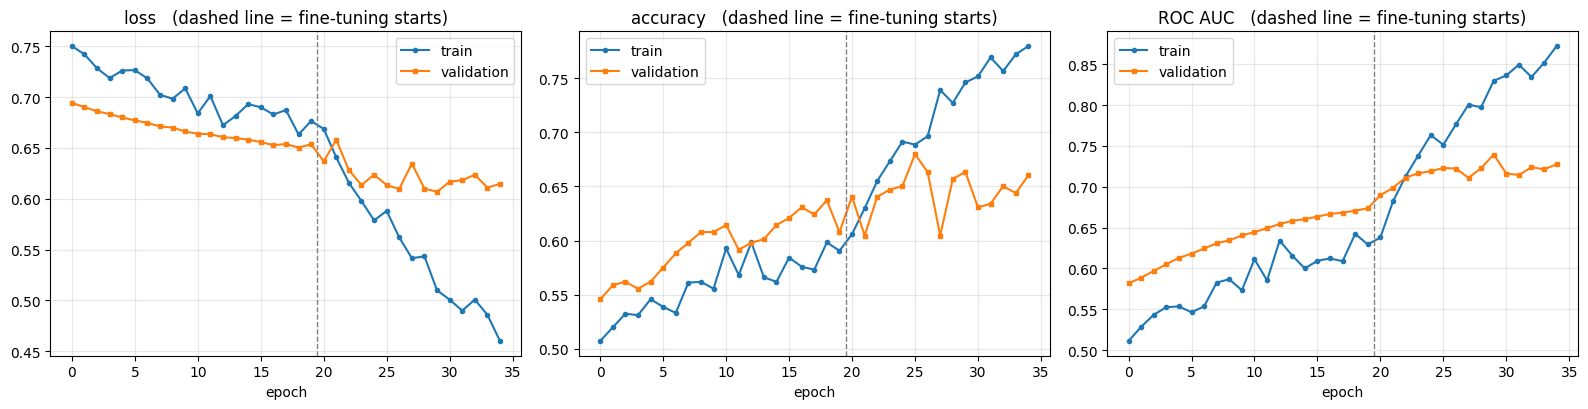

In [15]:
# Training curves across both stages.
def joined(key):
    return history1.history[key] + history2.history.get(key, [])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (key, title) in zip(axes, [("loss", "loss"), ("accuracy", "accuracy"),
                                   ("auc_roc", "ROC AUC")]):
    ax.plot(joined(key), marker="o", ms=3, label="train")
    ax.plot(joined("val_" + key), marker="s", ms=3, label="validation")
    ax.axvline(len(history1.history["loss"]) - 0.5, color="grey", ls="--", lw=1)
    ax.set_title(f"{title}   (dashed line = fine-tuning starts)")
    ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Choosing the operating threshold — on **validation**

0.5 is only the right cut-off when the classes are balanced *and* the two kinds of
mistake cost the same. Neither is true here.

The threshold is picked on the validation split by **Youden's J** (maximise
`TPR - FPR`), and then applied to the test split unchanged. Picking it on the data
you report is a way of making a weak model look strong.

In [16]:
def probabilities(model, ds):
    return tf.sigmoid(model.predict(ds, verbose=0).reshape(-1)).numpy()

val_p = probabilities(model, val_ds)
val_y = val_df["label"].to_numpy()
assert len(val_p) == len(val_y)           # the pipeline is unshuffled, so these align

fpr, tpr, thresholds = roc_curve(val_y, val_p)
best = int(np.argmax(tpr - fpr))
THRESHOLD = float(thresholds[best])

print(f"threshold (Youden's J) : {THRESHOLD:.4f}")
print(f"validation AUC         : {roc_auc_score(val_y, val_p):.4f}")
print(f"at that threshold      : TPR {tpr[best]:.3f}, FPR {fpr[best]:.3f}")
print("\nDecision rule from here on:")
print("  probability = sigmoid(model output) = P(real)")
print("  predicted   = CLASS_NAMES[int(probability >= THRESHOLD)]")

threshold (Youden's J) : 0.3867
validation AUC         : 0.7394
at that threshold      : TPR 0.765, FPR 0.389

Decision rule from here on:
  probability = sigmoid(model output) = P(real)
  predicted   = CLASS_NAMES[int(probability >= THRESHOLD)]


## 10. Evaluation on the sealed test split

First and last time these images are used.

There is deliberately no R² here: it is a regression statistic for a continuous
target and means little for a yes/no label. The appropriate probabilistic scores
— Brier score, log loss and a calibration curve — are below, and every headline
number comes with the majority-class baseline and a bootstrap confidence interval
next to it.

In [17]:
test_p = probabilities(model, test_ds)
test_y = test_df["label"].to_numpy()
test_pred = (test_p >= THRESHOLD).astype(int)

accuracy = float((test_pred == test_y).mean())
baseline = float(np.bincount(test_y).max() / len(test_y))
auc_roc = float(roc_auc_score(test_y, test_p))

# Bootstrap confidence intervals: on ~300 images a point estimate alone overstates
# how much we know.
rng = np.random.default_rng(SEED)
boot_acc, boot_auc = [], []
for _ in range(CONFIG["bootstrap"]):
    idx = rng.integers(0, len(test_y), len(test_y))
    if len(np.unique(test_y[idx])) < 2:
        continue
    boot_acc.append(((test_p[idx] >= THRESHOLD).astype(int) == test_y[idx]).mean())
    boot_auc.append(roc_auc_score(test_y[idx], test_p[idx]))
ci = lambda v: (float(np.quantile(v, 0.025)), float(np.quantile(v, 0.975)))
acc_ci, auc_ci = ci(boot_acc), ci(boot_auc)

matrix = confusion_matrix(test_y, test_pred, labels=[0, 1])
tn, fp, fn, tp = matrix.ravel()

print("=" * 62)
print(f"SEALED TEST SPLIT — {len(test_y)} images")
print("=" * 62)
print(f"accuracy            {accuracy:.4f}   95% CI [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]")
print(f"majority baseline   {baseline:.4f}")
print(f"lift over baseline  {accuracy - baseline:+.4f}   <- this is the real result")
print(f"balanced accuracy   {0.5 * (tp / (tp + fn) + tn / (tn + fp)):.4f}")
print(f"ROC AUC             {auc_roc:.4f}   95% CI [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")
print(f"PR AUC (fake)       {average_precision_score(1 - test_y, 1 - test_p):.4f}")
print(f"PR AUC (real)       {average_precision_score(test_y, test_p):.4f}")
print(f"log loss            {log_loss(test_y, np.clip(test_p, 1e-7, 1 - 1e-7)):.4f}")
print(f"Brier score         {brier_score_loss(test_y, test_p):.4f}")
print(f"threshold used      {THRESHOLD:.4f}   (chosen on validation, not here)")
print()
print("confusion matrix (rows actual, columns predicted):")
print(pd.DataFrame(matrix, index=[f"actual {c}" for c in CLASS_NAMES],
                   columns=[f"pred {c}" for c in CLASS_NAMES]).to_string())
print()
print(classification_report(test_y, test_pred, labels=[0, 1], target_names=CLASS_NAMES,
                            zero_division=0))

SEALED TEST SPLIT — 306 images
accuracy            0.6569   95% CI [0.604, 0.709]
majority baseline   0.5294
lift over baseline  +0.1275   <- this is the real result
balanced accuracy   0.6551
ROC AUC             0.7004   95% CI [0.642, 0.759]
PR AUC (fake)       0.6736
PR AUC (real)       0.6985
log loss            0.6573
Brier score         0.2312
threshold used      0.3867   (chosen on validation, not here)

confusion matrix (rows actual, columns predicted):
             pred fake  pred real
actual fake         90         54
actual real         51        111

              precision    recall  f1-score   support

        fake       0.64      0.62      0.63       144
        real       0.67      0.69      0.68       162

    accuracy                           0.66       306
   macro avg       0.66      0.66      0.66       306
weighted avg       0.66      0.66      0.66       306



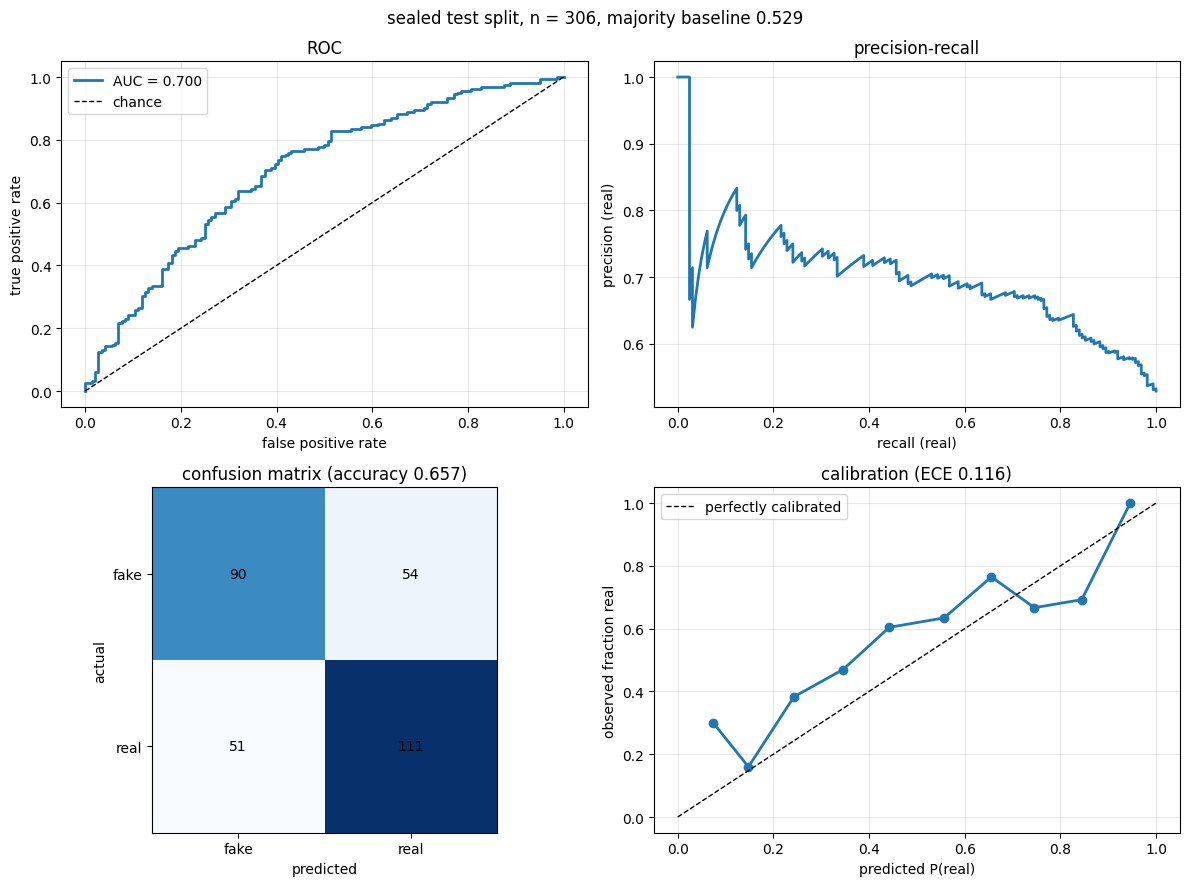

In [18]:
# ROC, precision-recall, confusion matrix, calibration.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

f, t, _ = roc_curve(test_y, test_p)
axes[0, 0].plot(f, t, lw=2, label=f"AUC = {auc_roc:.3f}")
axes[0, 0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
axes[0, 0].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

precision, recall, _ = precision_recall_curve(test_y, test_p)
axes[0, 1].plot(recall, precision, lw=2)
axes[0, 1].set(xlabel="recall (real)", ylabel="precision (real)", title="precision-recall")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].imshow(matrix, cmap="Blues")
axes[1, 0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=CLASS_NAMES,
               yticklabels=CLASS_NAMES, xlabel="predicted", ylabel="actual",
               title=f"confusion matrix (accuracy {accuracy:.3f})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, int(matrix[i, j]), ha="center", va="center")

edges = np.linspace(0, 1, 11)
bin_of = np.clip(np.digitize(test_p, edges) - 1, 0, 9)
xs, ys, ece = [], [], 0.0
for b in range(10):
    mask = bin_of == b
    if mask.any():
        xs.append(test_p[mask].mean()); ys.append(test_y[mask].mean())
        ece += mask.mean() * abs(test_y[mask].mean() - test_p[mask].mean())
axes[1, 1].plot(xs, ys, "o-", lw=2)
axes[1, 1].plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
axes[1, 1].set(xlabel="predicted P(real)", ylabel="observed fraction real",
               title=f"calibration (ECE {ece:.3f})")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.suptitle(f"sealed test split, n = {len(test_y)}, majority baseline {baseline:.3f}")
plt.tight_layout(); plt.savefig(CONFIG["out_dir"] / "evaluation.png", dpi=130); plt.show()

In [19]:
# Two breakdowns a single accuracy number hides.
print("accuracy by CIPLAB difficulty tier")
print("-" * 40)
by_tier = (test_df.assign(correct=(test_pred == test_y))
           .groupby("difficulty")["correct"].agg(["size", "mean"]))
by_tier.columns = ["n", "accuracy"]
print(by_tier.round(4).to_string())
print("('none' is the real images. Tiers are ~30 images each, so read them loosely.)")

margin = CONFIG["abstain_margin"]
uncertain = np.abs(test_p - THRESHOLD) < margin
decided_acc = float((test_pred[~uncertain] == test_y[~uncertain]).mean())
print(f"\nabstain band of +/-{margin} around the threshold")
print("-" * 40)
print(f"sent to human review : {uncertain.sum()} of {len(test_y)} ({uncertain.mean():.1%})")
print(f"accuracy on the rest : {decided_acc:.4f}  (vs {accuracy:.4f} deciding everything)")

accuracy by CIPLAB difficulty tier
----------------------------------------
              n  accuracy
difficulty               
easy         32    0.3750
hard         31    0.6774
mid          81    0.7037
none        162    0.6852
('none' is the real images. Tiers are ~30 images each, so read them loosely.)

abstain band of +/-0.1 around the threshold
----------------------------------------
sent to human review : 112 of 306 (36.6%)
accuracy on the rest : 0.6959  (vs 0.6569 deciding everything)


## 11. Grad-CAM — what the model looks at

Two textbook pitfalls are avoided here. Looking the last conv layer up by name
(`out_relu`) fails because MobileNetV2 is a *nested* model and its internal
layers are not visible from the outside; and differentiating the sigmoid gives
gradients that vanish once it saturates.

This version takes the tensor feeding `GlobalAveragePooling2D` — which *is* the
backbone's final feature map and does live in the outer graph — and differentiates
the logit. It never mentions a layer name, so it works with any backbone.

Read it with the accuracy above in mind: attribution shows where a model looked,
not whether it was right.

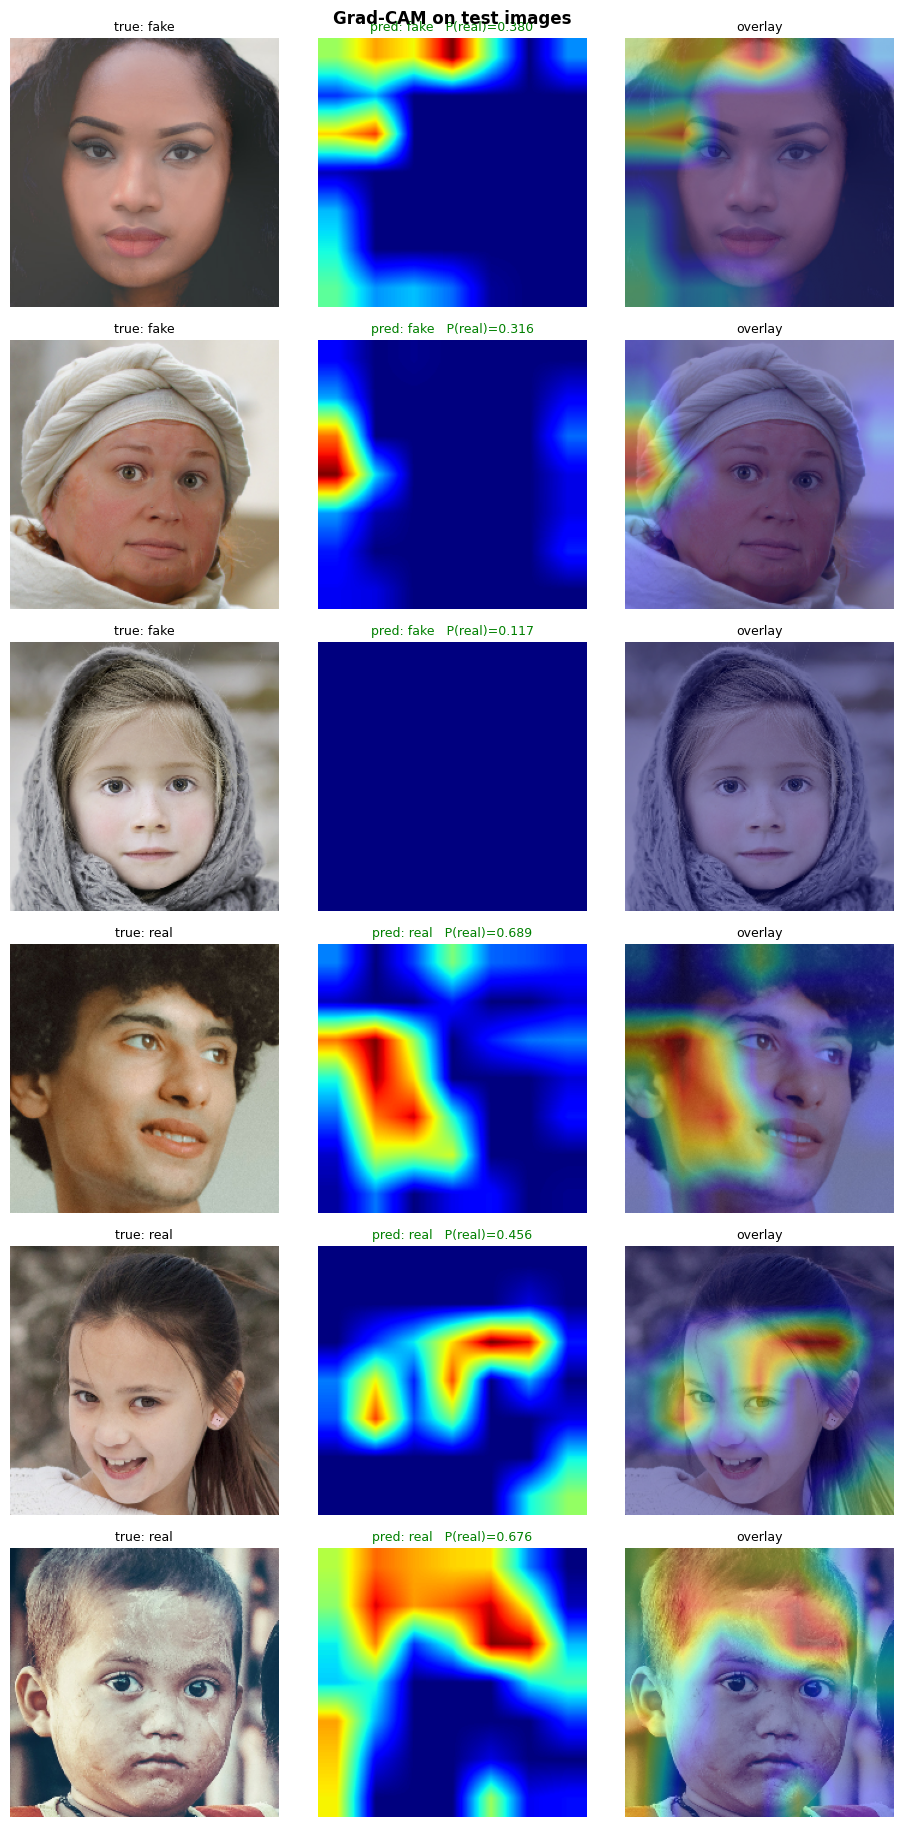

In [20]:
def grad_cam(model, image):
    gap = model.get_layer("gap")
    grad_model = keras.Model(model.inputs, [gap.input, model.output])
    batch = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        features, logit = grad_model(batch, training=False)
        tape.watch(features)
        score = logit[:, 0]                       # the LOGIT, not the sigmoid
    grads = tape.gradient(score, features)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.maximum(tf.reduce_sum(features[0] * weights, axis=-1), 0)
    peak = tf.reduce_max(cam)
    return (cam / peak).numpy() if peak > 0 else cam.numpy()

def load_image(path, size):
    image = tf.io.decode_image(tf.io.read_file(str(path)), channels=3, expand_animations=False)
    return tf.cast(tf.image.resize(image, size, method="bilinear"), tf.float32).numpy()

picks = pd.concat([test_df[test_df.label == 0].sample(3, random_state=SEED),
                   test_df[test_df.label == 1].sample(3, random_state=SEED)])

fig, axes = plt.subplots(len(picks), 3, figsize=(9.5, 3.1 * len(picks)))
for row, (_, record) in enumerate(picks.iterrows()):
    image = load_image(record["path"], CONFIG["image_size"])
    cam = grad_cam(model, image)
    probability = float(tf.sigmoid(model.predict(image[None, ...], verbose=0)[0][0]))
    predicted = CLASS_NAMES[int(probability >= THRESHOLD)]
    heat = tf.image.resize(cam[..., None], CONFIG["image_size"]).numpy()[..., 0]

    axes[row, 0].imshow(image.astype("uint8"))
    axes[row, 0].set_title(f"true: {record['class_name']}", fontsize=9)
    axes[row, 1].imshow(heat, cmap="jet")
    axes[row, 1].set_title(f"pred: {predicted}   P(real)={probability:.3f}",
                           fontsize=9,
                           color="green" if predicted == record["class_name"] else "red")
    axes[row, 2].imshow(image.astype("uint8") / 255.0)
    axes[row, 2].imshow(heat, cmap="jet", alpha=0.4)
    axes[row, 2].set_title("overlay", fontsize=9)
    for col in range(3):
        axes[row, col].axis("off")

plt.suptitle("Grad-CAM on test images", fontweight="bold")
plt.tight_layout(); plt.savefig(CONFIG["out_dir"] / "gradcam.png", dpi=130); plt.show()

## 12. Inference on new images

Polarity is derived, never hardcoded. `CLASS_NAMES = ["fake", "real"]`, so index 1
is *real* and the sigmoid output is **P(real)**. A high probability means REAL.
Writing the class name as a string literal anywhere in the decision path would
create a second source of truth that can silently contradict the index.

Here the name is always `CLASS_NAMES[int(probability >= threshold)]`, and the cell
asserts that the returned class and label agree.

easy_198_0011.jpg                  true=fake  -> fake      P(real)=0.245
mid_416_1111.jpg                   true=fake  -> uncertain P(real)=0.446
hard_14_1111.jpg                   true=fake  -> uncertain P(real)=0.329
real_00708.jpg                     true=real  -> uncertain P(real)=0.353
real_00579.jpg                     true=real  -> fake      P(real)=0.175
real_00238.jpg                     true=real  -> uncertain P(real)=0.451


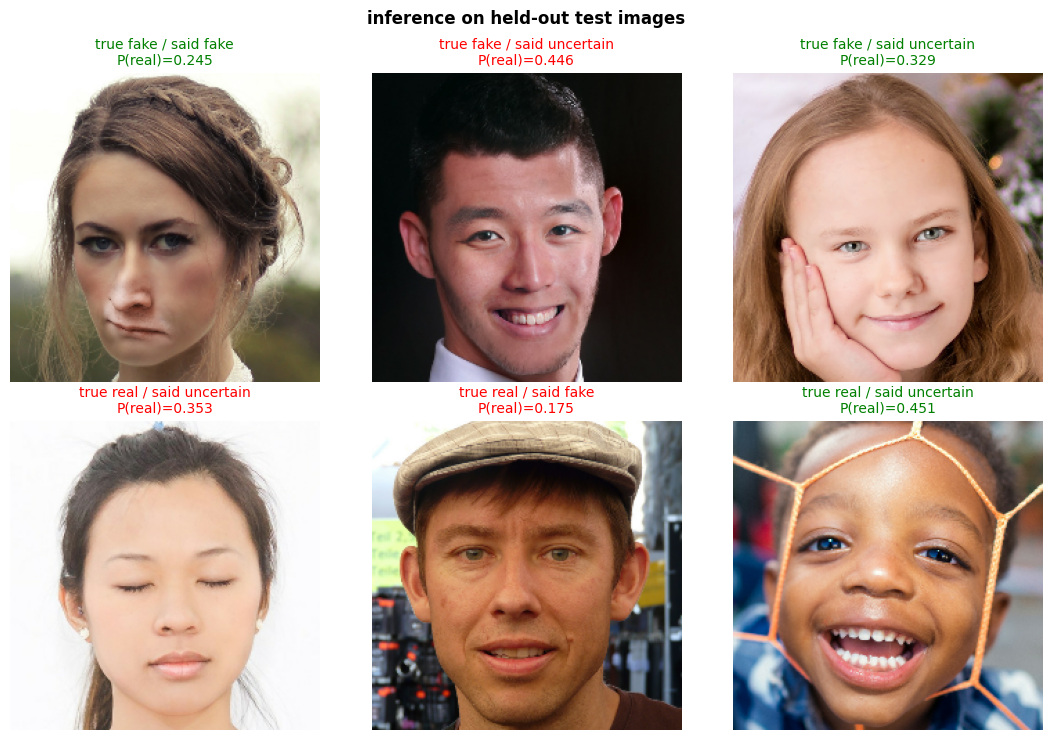


class and label agreed on every row.


In [21]:
def predict_image(path, model, threshold=None, abstain_margin=0.0):
    """Classify one image file. Returns P(real), the class, and a decision."""
    threshold = THRESHOLD if threshold is None else threshold
    image = load_image(path, CONFIG["image_size"])       # same decode+resize as training
    logit = float(model.predict(image[None, ...], verbose=0)[0][0])
    probability = float(tf.sigmoid(logit))               # model emits a logit
    index = int(probability >= threshold)
    name = CLASS_NAMES[index]                            # derived, never a literal
    uncertain = abs(probability - threshold) < abstain_margin
    return {"path": str(path), "probability_real": round(probability, 4),
            "probability_fake": round(1 - probability, 4),
            "predicted_class": name, "label": name,
            "decision": "uncertain" if uncertain else name}

demo = pd.concat([test_df[test_df.label == 0].sample(3, random_state=7),
                  test_df[test_df.label == 1].sample(3, random_state=7)])

fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))
for ax, (_, record) in zip(axes.ravel(), demo.iterrows()):
    result = predict_image(record["path"], model, abstain_margin=CONFIG["abstain_margin"])
    assert result["predicted_class"] == result["label"]     # class and label must agree
    correct = result["predicted_class"] == record["class_name"]
    ax.imshow(load_image(record["path"], CONFIG["image_size"]).astype("uint8")); ax.axis("off")
    ax.set_title(f"true {record['class_name']} / said {result['decision']}\n"
                 f"P(real)={result['probability_real']:.3f}",
                 fontsize=10, color="green" if correct else "red")
    print(f"{record['filename'][:34]:34s} true={record['class_name']:5s} "
          f"-> {result['decision']:9s} P(real)={result['probability_real']:.3f}")

plt.suptitle("inference on held-out test images", fontweight="bold")
plt.tight_layout(); plt.show()
print("\nclass and label agreed on every row.")

## 13. Save everything

The model is saved with `model.save()` to `.keras`, never pickled: pickling a live
Keras object ties the file to one exact TensorFlow build and one pickle protocol,
while the native format survives upgrades.

Weights alone are not deployable. What ships is the weights **plus** the class
order, the image size, the preprocessing description and the operating threshold —
so `label_map.json` carries all four.

In [22]:
model_path = CONFIG["out_dir"] / "model.keras"
model.save(model_path)

label_map = {
    "class_names": CLASS_NAMES,
    "class_indices": {name: i for i, name in enumerate(CLASS_NAMES)},
    "positive_class": "real",
    "output": "logit",
    "probability": "sigmoid(logit) = P(real)",
    "decision_rule": "class_names[int(probability >= threshold)]",
    "threshold": THRESHOLD,
    "image_size": list(CONFIG["image_size"]),
    "color_order": "RGB",
    "preprocessing": "inside the model: Rescaling(1/127.5, offset=-1) -> [-1, 1]",
    "backbone": "MobileNetV2",
}
(CONFIG["out_dir"] / "label_map.json").write_text(json.dumps(label_map, indent=2))

metrics = {
    "n_test": int(len(test_y)),
    "accuracy": round(accuracy, 4),
    "accuracy_95ci": [round(acc_ci[0], 4), round(acc_ci[1], 4)],
    "majority_baseline": round(baseline, 4),
    "lift_over_baseline": round(accuracy - baseline, 4),
    "auc_roc": round(auc_roc, 4),
    "auc_roc_95ci": [round(auc_ci[0], 4), round(auc_ci[1], 4)],
    "brier": round(float(brier_score_loss(test_y, test_p)), 4),
    "log_loss": round(float(log_loss(test_y, np.clip(test_p, 1e-7, 1 - 1e-7))), 4),
    "calibration_ece": round(float(ece), 4),
    "threshold": round(THRESHOLD, 4),
    "confusion_matrix": matrix.tolist(),
    "selected_stage": winner,
    "validation_auc": round(float(winner_auc), 4),
}
(CONFIG["out_dir"] / "metrics.json").write_text(json.dumps(metrics, indent=2))

# The most confident mistakes, which is where the next idea comes from.
mistakes = test_df.assign(probability_real=test_p, predicted=test_pred)
mistakes = mistakes[mistakes.predicted != mistakes.label]
mistakes = mistakes.assign(margin=(mistakes.probability_real - THRESHOLD).abs())
mistakes.sort_values("margin", ascending=False).to_csv(
    CONFIG["out_dir"] / "worst_mistakes.csv", index=False)

for name in ("model.keras", "label_map.json", "metrics.json", "worst_mistakes.csv",
             "evaluation.png", "gradcam.png", "split_manifest.csv"):
    path = CONFIG["out_dir"] / name
    print(f"saved {str(path):55s} {path.stat().st_size / 1024:9.1f} KB")

print("\nreload later with:")
print("  model = keras.models.load_model('artifacts/notebook/model.keras')")
print("  contract = json.load(open('artifacts/notebook/label_map.json'))")
print("  probability = float(tf.sigmoid(model.predict(image[None])[0][0]))")
print("  predicted = contract['class_names'][int(probability >= contract['threshold'])]")

saved artifacts\notebook\model.keras                            22426.3 KB
saved artifacts\notebook\label_map.json                             0.5 KB
saved artifacts\notebook\metrics.json                               0.5 KB
saved artifacts\notebook\worst_mistakes.csv                        11.9 KB
saved artifacts\notebook\evaluation.png                           126.2 KB
saved artifacts\notebook\gradcam.png                             2382.5 KB
saved artifacts\notebook\split_manifest.csv                       181.9 KB

reload later with:
  model = keras.models.load_model('artifacts/notebook/model.keras')
  contract = json.load(open('artifacts/notebook/label_map.json'))
  probability = float(tf.sigmoid(model.predict(image[None])[0][0]))
  predicted = contract['class_names'][int(probability >= contract['threshold'])]


## 14. Reading the result

Read the printed numbers above, not this text. What they mean:

- The number that matters is **lift over the majority-class baseline**, not accuracy.
  Predicting `real` for every image already scores the baseline.
- **ROC AUC is the more trustworthy figure** because it does not depend on the
  threshold. Accuracy moves when only the cut-off changes, without the model
  changing at all.
- The confidence intervals are wide because the test split is ~300 images. If two
  numbers' intervals overlap, the difference between them is not established.

### Why this is not a strong detector, and what would actually help

The limit is not the head; it is what reaches the head. Forgery traces are
**high-frequency and local** — blending seams, noise inconsistency, compression
history — and this pipeline destroys them twice: once resizing ~600 px images down
to 224, and again by global-average-pooling a 7x7 grid into 1,280 numbers that no
longer say *where* anything happened.

Ranked by expected payoff:

1. **Higher input resolution.** Set `CONFIG["image_size"] = (384, 384)` and re-run
   from section 6. Costs about 3x the training time.
2. **Crop to the aligned face** (MTCNN, RetinaFace, MediaPipe) and classify the crop
   at native resolution instead of the whole downsampled frame.
3. **A frequency branch** — DCT coefficients or SRM high-pass residuals alongside RGB.
   This is the domain-specific move that separates a forensics model from a generic
   image classifier.
4. **Use the region masks** already parsed in section 3 (`region_mask`) as extra
   supervision: predict *which* region was manipulated, not just whether one was.
5. **Random JPEG re-compression** as augmentation, which is the kind of noise a
   forensic model should be robust to.
6. **Cross-dataset testing** on FaceForensics++ or Celeb-DF. Expect a big drop, and
   report it — that drop is the finding, not a failure.

### Do not deploy this

The fakes here are Photoshop composites, not GAN output, so this model says nothing
about AI-generated faces. At this accuracy a positive result means "worth a human
look", never evidence about a real person. That is what the abstain band in section
10 is for.

---

The same code also exists as a tested package in `src/deepfake/` with a command
line (`python -m deepfake.cli all`) and 57 tests, for when you want to run
experiments without a browser. This notebook and that package are independent —
you never need both.